<a href="https://colab.research.google.com/github/Gabzedu/personal-expenses-analysis/blob/main/notebooks/expenses_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personal Finances Analysis (2022–2025)

## 1. Problem Statement

This project analyses personal income and expense data recorded between 2022 and 2025.

The goal is to understand financial evolution over time, identify spending patterns by category, and evaluate savings performance across years.

**Key questions:**
- How did income and expenses evolve year over year?
- Which categories represent the largest share of spending?
- What is the savings trend over time?

> **Note:** 2026 data is excluded from this analysis as the year is incomplete and would distort annual comparisons.


## 2. Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving expenses_all_years.xlsx to expenses_all_years.xlsx


In [7]:
income = pd.read_excel('expenses_all_years.xlsx', sheet_name='Income')
expenses = pd.read_excel('expenses_all_years.xlsx', sheet_name='Expenses')

print("Income shape:", income.shape)
print("Expenses shape:", expenses.shape)

Income shape: (199, 11)
Expenses shape: (547, 12)


## 3. Data Cleaning & Transformation

In [8]:
# Strip whitespace from Month column (both sheets)
income['Month'] = income['Month'].str.strip()
expenses['Month'] = expenses['Month'].str.strip()

# Define month order for sorting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert Month to ordered categorical
income['Month'] = pd.Categorical(income['Month'], categories=month_order, ordered=True)
expenses['Month'] = pd.Categorical(expenses['Month'], categories=month_order, ordered=True)

# Convert Year and Amount to numeric
income['Year'] = pd.to_numeric(income['Year'])
income['Amount '] = pd.to_numeric(income['Amount '], errors='coerce')

expenses['Year'] = pd.to_numeric(expenses['Year'])
expenses['Amount'] = pd.to_numeric(expenses['Amount'], errors='coerce')

# Filter out 2026
income = income[income['Year'] <= 2025]
expenses = expenses[expenses['Year'] <= 2025]

print("Income after cleaning:", income.shape)
print("Expenses after cleaning:", expenses.shape)
print("\nYears in Income:", sorted(income['Year'].unique()))
print("Years in Expenses:", sorted(expenses['Year'].unique()))

Income after cleaning: (195, 11)
Expenses after cleaning: (534, 12)

Years in Income: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Years in Expenses: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 4. Exploratory Data Analysis

In [9]:
# Rename income amount column (has a trailing space)
income = income.rename(columns={'Amount ': 'Amount'})

# Total income and expenses by year
yearly_income = income.groupby('Year')['Amount'].sum().reset_index()
yearly_income.columns = ['Year', 'Total_Income']

yearly_expenses = expenses.groupby('Year')['Amount'].sum().reset_index()
yearly_expenses.columns = ['Year', 'Total_Expenses']

# Merge into one summary table
yearly_summary = pd.merge(yearly_income, yearly_expenses, on='Year')
yearly_summary['Net_Savings'] = yearly_summary['Total_Income'] - yearly_summary['Total_Expenses']
yearly_summary['Savings_Rate'] = (yearly_summary['Net_Savings'] / yearly_summary['Total_Income'] * 100).round(1)

print(yearly_summary.to_string(index=False))

 Year  Total_Income  Total_Expenses  Net_Savings  Savings_Rate
 2022       9266.59         8671.03       595.56           6.4
 2023      15449.53        14102.72      1346.81           8.7
 2024      17709.07        15402.63      2306.44          13.0
 2025      22960.15        18448.26      4511.89          19.7


In [10]:
# Average expenses by subcategory (across all years)
category_expenses = expenses.groupby('Subcategory')['Amount'].sum().reset_index()
category_expenses.columns = ['Subcategory', 'Total_Amount']
category_expenses = category_expenses.sort_values('Total_Amount', ascending=False)

print(category_expenses.to_string(index=False))

             Subcategory  Total_Amount
                    Rent      16975.00
                Shopping       8065.61
               Groceries       7980.74
      Projects & Studies       5295.78
          Transportation       4515.79
              Eating Out       4124.43
                  Travel       4088.71
                   Bills       3417.21
            Dog supplies        883.99
             Veterinary         335.29
                 Unknown        321.92
Subscriptions & Services        287.87
                  Health        189.00
                 Health         131.94
                    Card         11.36


In [11]:
# Fix duplicate Health category and clean subcategories
expenses['Subcategory'] = expenses['Subcategory'].str.strip().str.title()

# Verify fix
category_expenses = expenses.groupby('Subcategory')['Amount'].sum().reset_index()
category_expenses.columns = ['Subcategory', 'Total_Amount']
category_expenses = category_expenses.sort_values('Total_Amount', ascending=False)

print(category_expenses.to_string(index=False))

             Subcategory  Total_Amount
                    Rent      16975.00
                Shopping       8065.61
               Groceries       7980.74
      Projects & Studies       5295.78
          Transportation       4515.79
              Eating Out       4124.43
                  Travel       4088.71
                   Bills       3417.21
            Dog Supplies        883.99
              Veterinary        335.29
                 Unknown        321.92
                  Health        320.94
Subscriptions & Services        287.87
                    Card         11.36


In [12]:
# Rename Card to Bank Fees
expenses['Subcategory'] = expenses['Subcategory'].replace('Card', 'Bank Fees')

# Verify
category_expenses = expenses.groupby('Subcategory')['Amount'].sum().reset_index()
category_expenses.columns = ['Subcategory', 'Total_Amount']
category_expenses = category_expenses.sort_values('Total_Amount', ascending=False)

print(category_expenses.to_string(index=False))

             Subcategory  Total_Amount
                    Rent      16975.00
                Shopping       8065.61
               Groceries       7980.74
      Projects & Studies       5295.78
          Transportation       4515.79
              Eating Out       4124.43
                  Travel       4088.71
                   Bills       3417.21
            Dog Supplies        883.99
              Veterinary        335.29
                 Unknown        321.92
                  Health        320.94
Subscriptions & Services        287.87
               Bank Fees         11.36


## 5. Visualisation & Insights

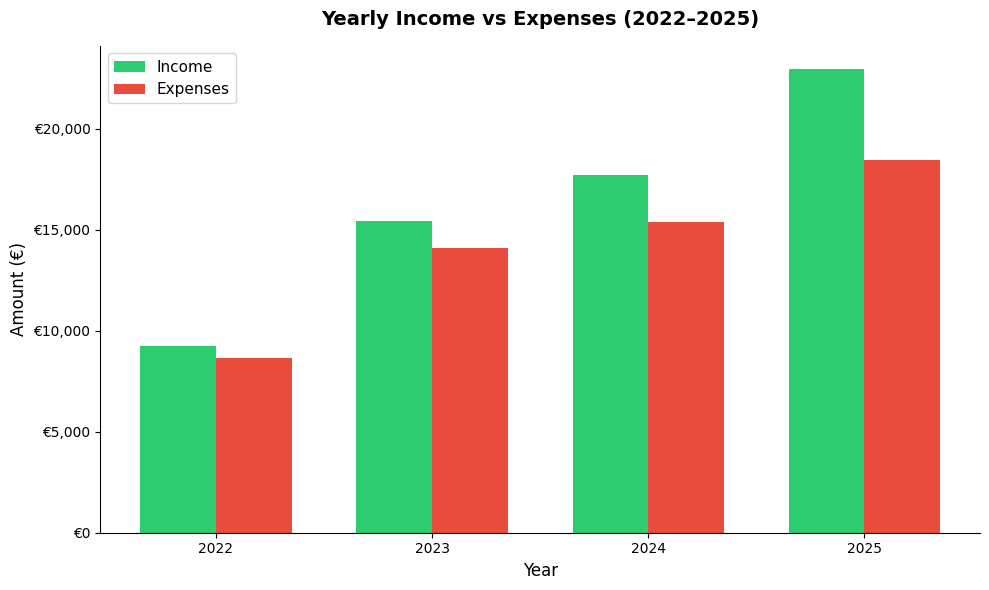

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

x = yearly_summary['Year']
width = 0.35
bars1 = ax.bar(x - width/2, yearly_summary['Total_Income'], width, label='Income', color='#2ecc71')
bars2 = ax.bar(x + width/2, yearly_summary['Total_Expenses'], width, label='Expenses', color='#e74c3c')

ax.set_title('Yearly Income vs Expenses (2022–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Amount (€)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(yearly_summary['Year'])
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'€{val:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('yearly_income_expenses.png', dpi=150, bbox_inches='tight')
plt.show()

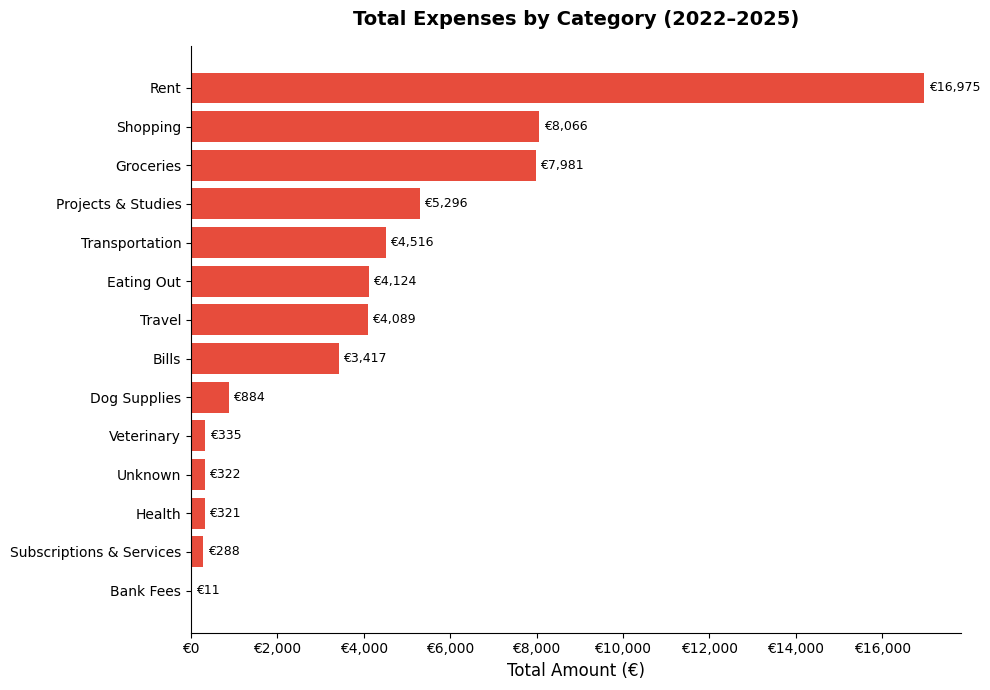

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if i == 0 else '#c0392b' if i == 1 else '#e67e22' if i < 4 else '#95a5a6'
          for i in range(len(category_expenses))]

bars = ax.barh(category_expenses['Subcategory'], category_expenses['Total_Amount'], color='#e74c3c')

ax.set_title('Total Expenses by Category (2022–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Amount (€)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'€{val:,.0f}'))
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, category_expenses['Total_Amount']):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('category_expenses.png', dpi=150, bbox_inches='tight')
plt.show()

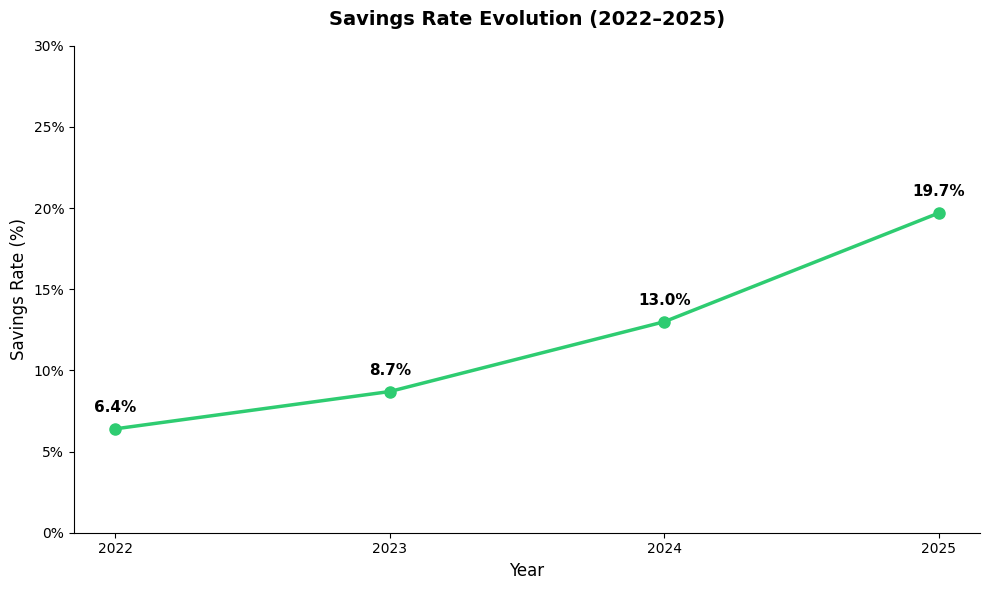

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_summary['Year'], yearly_summary['Savings_Rate'],
        marker='o', linewidth=2.5, markersize=8, color='#2ecc71')

for _, row in yearly_summary.iterrows():
    ax.annotate(f"{row['Savings_Rate']}%",
                xy=(row['Year'], row['Savings_Rate']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold')

ax.set_title('Savings Rate Evolution (2022–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Savings Rate (%)', fontsize=12)
ax.set_xticks(yearly_summary['Year'])
ax.set_ylim(0, 30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0f}%'))

plt.tight_layout()
plt.savefig('savings_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Insights

- Income grew from €9,267 in 2022 to €22,960 in 2025 — a 148% increase over four years.
- Expenses grew at a slower pace, from €8,671 to €18,448 — a 113% increase.
- Net savings improved every year, from €596 in 2022 to €4,512 in 2025.
- Savings rate increased consistently from 6.4% to 19.7%.
- Rent is the largest expense category (€16,975).
- Shopping and Groceries are the second and third largest categories (€8,066 and €7,981).
- Projects & Studies (€5,296) reflects investment in education and trading during this period.

## 7. Conclusions & Next Steps

**Conclusions:**
- Financial performance improved significantly between 2022 and 2025.
- Income growth consistently outpaced expense growth, resulting in a stronger savings position each year.
- Discretionary spending (Shopping, Eating Out, Travel) represents a significant share of expenses and is an area with potential for optimisation.

**Next Steps:**
- Build an interactive dashboard in Tableau for deeper exploration.
- Analyse monthly spending patterns within each year.
- Track progress into 2026 when the full year is available.